### Partie 1 – Exploration du corpus 

##### 1) Charger les données CSV 

In [198]:
import pandas as pd
df = pd.read_csv("../data/smart_reviews_raw.csv")
df

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr
...,...,...,...,...,...,...,...,...
1195,AV1196,2026-08-07,mobile,SmartPhone Y,La batterie se décharge beaucoup trop vite.,negatif,2,fr
1196,AV1197,2026-01-31,email,Écouteurs AirSound,"Très bonne expérience, simple et efficace. !!!",positif,5,fr
1197,AV1198,2026-04-02,web,SmartWatch Pro,Produit correct pour son prix. !!!,neutre,4,fr
1198,AV1199,2026-05-02,email,Tablette TabPlus,Excellent rapport qualité-prix. #avis,positif,5,fr


##### 2) Combien d'avis contient le dataset 

In [199]:
print("le nombre d'avis est : \n" , df.shape[0])

le nombre d'avis est : 
 1200


##### 3) Combien de colonnes possède-t-il

In [200]:
print("le nombre de colonne que possede le dataset est :\n", df.shape[1])

le nombre de colonne que possede le dataset est :
 8


##### 4) Quel est le type de chaque colonne 

In [201]:
print("le type de chaque colonne est :\n", df.dtypes)

le type de chaque colonne est :
 id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object


##### 5) Existe-t-il des valeurs manquantes ?

In [202]:
print("nombre de valeur manquante : \n", df.isna().sum())

nombre de valeur manquante : 
 id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64


Oui , il existe des valeurs manquantes au nombre de 5 au niveau e la colonne texte qui represente les avis.

##### 6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec répétition de caractères. 

In [203]:
import re
# 2. Définition de la fonction d'identification du type de texte
def identifier_type_texte(texte):
    # Gestion du texte vide ou ne contenant que des espaces
    if not str(texte).strip():
        return "texte vide"
        
    texte_str = str(texte)
    
    # Vérification des majuscules (au moins quelques lettres, et toutes en majuscules)
    if texte_str.isupper():
        return "texte en majuscules"
        
    # URL : commence par http, https ou www
    if re.search(r'https?://\S+|www\.\S+', texte_str):
        return "texte contenant une URL"
        
    # Mention : @ suivi de caractères alphanumériques
    if re.search(r'@\w+', texte_str):
        return "texte contenant une mention"
        
    # Hashtag : # suivi de caractères alphanumériques
    if re.search(r'#\w+', texte_str):
        return "texte contenant un hashtag"
        
    # Emojis : détection de la plage de caractères Unicode des emojis
    if re.search(r'[\U00010000-\U0010ffff]', texte_str):
        return "texte contenant des emojis"
        
    # Beaucoup de ponctuation 
    if re.search(r'[!?.,;:-]{3,}', texte_str):
        return "texte avec beaucoup de ponctuation"
        
    # Répétition de caractères 
    if re.search(r'(.)\1{2,}', texte_str):
        return "texte avec répétition de caractères"
        
    # Si aucun critère spécifique n'est rempli
    return "texte normal"

# 3. Application de la fonction sur le DataFrame
df['type_de_texte'] = df['texte'].apply(identifier_type_texte)

# 4. Affichage du résultat
df[['texte', 'type_de_texte']]

,texte,type_de_texte
0,"Très bonne expérience, simple et efficace.",texte normal
1,Très satisfait de mon achat 👍 #avis,texte contenant un hashtag
2,"Produit parfait, rien à signaler.",texte normal
3,"Produit excellent, je suis très satisfait. !!!",texte avec beaucoup de ponctuation
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,texte en majuscules
...,...,...
1195,La batterie se décharge beaucoup trop vite.,texte normal
1196,"Très bonne expérience, simple et efficace. !!!",texte avec beaucoup de ponctuation
1197,Produit correct pour son prix. !!!,texte avec beaucoup de ponctuation
1198,Excellent rapport qualité-prix. #avis,texte contenant un hashtag


##### 7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles. 

In [204]:
# 1. Création de la colonne « longueur » (nombre de caractères)
df['longueur'] = df['texte'].str.len()

# 2. Calcul et affichage des statistiques descriptives
statistiques = df['longueur'].describe()

print("--- Statistiques de longueur ---")
print(f"Longueur minimale : {statistiques['min']}")
print(f"Longueur maximale : {statistiques['max']}")
print(f"Longueur moyenne  : {statistiques['mean']:.2f}")
print(f"Médiane (50%)     : {statistiques['50%']}")
print(f"Premier quartile (25%)  : {statistiques['25%']}")
print(f"Troisième quartile (75%): {statistiques['75%']}")


--- Statistiques de longueur ---
Longueur minimale : 2.0
Longueur maximale : 636.0
Longueur moyenne  : 49.17
Médiane (50%)     : 48.0
Premier quartile (25%)  : 37.0
Troisième quartile (75%): 56.0


##### 8) Visualiser la distribution de la longueur des avis puis répondre aux questions 

C:\Users\dell\AppData\Local\Temp\ipykernel_9084\1371651433.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


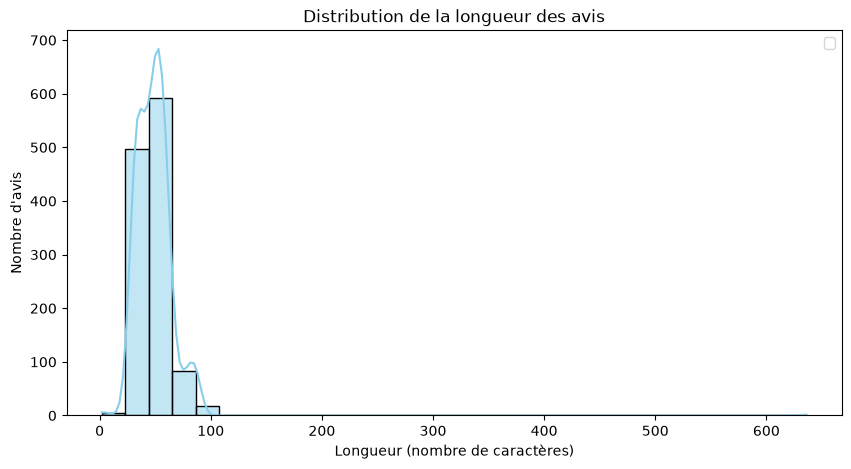

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Graphique : Histogramme avec courbe de densité
sns.histplot(df['longueur'], kde=True, color='skyblue', bins=30)
plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur (nombre de caractères)")
plt.ylabel("Nombre d'avis")


plt.legend()
plt.show()

##### a) Existe-t-il des textes anormalement longs ?

***Oui, le graphique met clairement en évidence la présence d'une valeur aberrante (outlier) à l'extrême droite. Alors que la quasi-totalité des avis ont une longueur standard concentrée entre 20 et 100 caractères, il existe au moins un texte anormalement long qui atteint environ 640 caractères.***

##### b) Existe-t-il beaucoup de textes très courts ? 

***Non, il y a très peu de textes excessivement courts. Le graphique montre que le nombre d'avis est presque nul en dessous de 20 caractères. La grande majorité des données commence à se densifier fortement à partir de 30 caractères, ce qui indique que les utilisateurs écrivent presque tous des messages d'une longueur minimale standard.***

##### 9) Détecter les textes vides

In [206]:
# on fait d'abord le filtrage pour ensuite afficher les textes vides
masque_vide = (df['texte'].str.strip() == '')

# Affiche des lignes correspondantes
df_vides = df[masque_vide]
df_vides

,id_avis,date,source,produit,texte,sentiment,note,langue,type_de_texte,longueur
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr,texte vide,3.0


##### 10) Détecter les doublons sur le texte 

In [207]:
doublons = df['texte'].duplicated()
df_doublons= df[doublons]
df_doublons

,id_avis,date,source,produit,texte,sentiment,note,langue,type_de_texte,longueur
11,AV0012,2026-06-25,email,SmartPhone X,"Produit parfait, rien à signaler.",positif,5,fr,texte normal,37.0
17,AV0018,2026-04-09,sav,Tablette TabPlus,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,positif,5,fr,texte en majuscules,52.0
27,AV0028,2026-04-26,web,SmartPhone Y,Excellent rapport qualité-prix.,positif,5,fr,texte normal,31.0
37,AV0038,2026-04-08,web,Écouteurs AirSound,"Produit excellent, je suis très satisfait. !!!",positif,5,fr,texte avec beaucoup de ponctuation,46.0
41,AV0042,2026-01-21,mobile,SmartPhone X,"Produit excellent, je suis trèèès satisfait.",positif,5,fr,texte avec répétition de caractères,44.0
...,...,...,...,...,...,...,...,...,...,...
1195,AV1196,2026-08-07,mobile,SmartPhone Y,La batterie se décharge beaucoup trop vite.,negatif,2,fr,texte normal,43.0
1196,AV1197,2026-01-31,email,Écouteurs AirSound,"Très bonne expérience, simple et efficace. !!!",positif,5,fr,texte avec beaucoup de ponctuation,46.0
1197,AV1198,2026-04-02,web,SmartWatch Pro,Produit correct pour son prix. !!!,neutre,4,fr,texte avec beaucoup de ponctuation,34.0
1198,AV1199,2026-05-02,email,Tablette TabPlus,Excellent rapport qualité-prix. #avis,positif,5,fr,texte contenant un hashtag,37.0


##### 11) Les classes sont-elles équilibrées ? 

In [208]:
# On Compte le nombre de lignes par classe(positif , neutre ou negatif)
print(df['sentiment'].value_counts())

# Puis on calcule les proportions en pourcentage
print(df['sentiment'].value_counts(normalize=True) * 100)


sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64
sentiment
positif    64.666667
neutre     20.500000
negatif    14.833333
Name: proportion, dtype: float64


***Non, les classes ne sont pas équilibrées. La classe 'positif' est largement majoritaire et représente à elle seule près des deux tiers des données (64,67 %), soit 776 avis.En comparaison, les classes 'neutre' (20,50 %) et 'négatif' (14,83 %) sont fortement minoritaires. Il y a un déséquilibre marqué.***

##### 12) Quelle est la classe majoritaire ? 

***La classe majoritaire est la classe 'Positif' avec un effectif de 776 et un pourcentage de 64.666667***

##### 13) Quelles métriques de classification à envisager d’utiliser ? 

Le jeu de données étant fortement déséquilibré, la métrique standard de l'Exactitude (Accuracy) est à proscrire car elle masquerait les mauvaises performances sur les classes minoritaires. Il faut envisager d'utiliser :

--Le F1-Score (notamment le Macro F1-score) comme indicateur global, car il traite équitablement chaque classe sans favoriser la classe majoritaire.

--Le Rappel (Recall) spécifiquement sur la classe 'négatif', afin de s'assurer que l'on capture un maximum de clients mécontents.

--La Matrice de Confusion pour analyser en détail les erreurs de prédiction entre les trois sentiments.

##### 14) Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères spéciaux ; ponctuation répétée ; 

In [209]:
# 1. Emojis 
df['a_emojis'] = df['texte'].str.contains(r'[\U00010000-\U0010ffff]', regex=True)

# 2. URLs
df['a_urls'] = df['texte'].str.contains(r'https?://\S+|www\.\S+', regex=True)

# 3. Hashtags 
df['a_hashtags'] = df['texte'].str.contains(r'#\w+', regex=True)

# 4. Mentions 
df['a_mentions'] = df['texte'].str.contains(r'@\w+', regex=True)

# 5. Chiffres 
df['a_chiffres'] = df['texte'].str.contains(r'\d', regex=True)

# 6. Ponctuation répétée 
# Exemple : !!, ??, ...
df['a_ponctuation_repetee'] = df['texte'].str.contains(r'[!?.,;:-]{2,}', regex=True)

# 7. Caractères spéciaux (Tout ce qui n'est ni une lettre, ni un chiffre, ni un espace)
df['a_caracteres_speciaux'] = df['texte'].str.contains(r'[^a-zA-Z0-9\sàâäéèêëîïôöùûüçÀÂÄÉÈÊËÎÏÔÖÙÛÜÇ]', regex=True)

df


,id_avis,date,source,produit,texte,sentiment,note,langue,type_de_texte,longueur,a_emojis,a_urls,a_hashtags,a_mentions,a_chiffres,a_ponctuation_repetee,a_caracteres_speciaux
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr,texte normal,47.0,False,False,False,False,False,False,True
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr,texte contenant un hashtag,35.0,True,False,True,False,False,False,True
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr,texte normal,37.0,False,False,False,False,False,False,True
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr,texte avec beaucoup de ponctuation,46.0,False,False,False,False,False,True,True
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr,texte en majuscules,55.0,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,AV1196,2026-08-07,mobile,SmartPhone Y,La batterie se décharge beaucoup trop vite.,negatif,2,fr,texte normal,43.0,False,False,False,False,False,False,True
1196,AV1197,2026-01-31,email,Écouteurs AirSound,"Très bonne expérience, simple et efficace. !!!",positif,5,fr,texte avec beaucoup de ponctuation,46.0,False,False,False,False,False,True,True
1197,AV1198,2026-04-02,web,SmartWatch Pro,Produit correct pour son prix. !!!,neutre,4,fr,texte avec beaucoup de ponctuation,34.0,False,False,False,False,False,True,True
1198,AV1199,2026-05-02,email,Tablette TabPlus,Excellent rapport qualité-prix. #avis,positif,5,fr,texte contenant un hashtag,37.0,False,False,True,False,False,False,True


##### 15) Visualiser et commenter nombre d'avis par source 

C:\Users\dell\AppData\Local\Temp\ipykernel_9084\3030174447.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='source', order=ordre, palette='viridis')


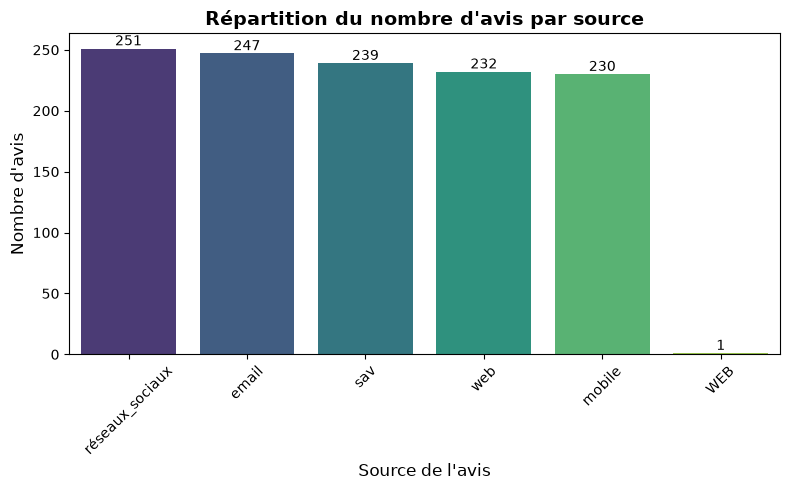

In [210]:
# Configuration de la taille du graphique
plt.figure(figsize=(8, 5))

ordre = df['source'].value_counts().index
sns.countplot(data=df, x='source', order=ordre, palette='viridis')

plt.title("Répartition du nombre d'avis par source", fontsize=14, fontweight='bold')
plt.xlabel("Source de l'avis", fontsize=12)
plt.ylabel("Nombre d'avis", fontsize=12)

# Rotation des étiquettes si les noms des sources sont longs
plt.xticks(rotation=45)

# Affichage des valeurs exactes au-dessus de chaque barre
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


***commentaire*** 

Une répartition globale très homogène (équilibrée)Si l'on exclut la dernière barre, on observe que le nombre d'avis est remarquablement équilibré entre les 5 sources principales. Le volume d'avis oscille de manière très serrée entre 230 et 251 avis par canal :

--réseaux_sociaux est la source principale avec 251 avis.

--email suit de très près avec 247 avis.

--sav (Service Après-Vente) comptabilise 239 avis.

--web enregistre 232 avis.

--mobile ferme la marche de ce groupe principal avec 230 avis.

Cette homogénéité indique que les utilisateurs utilisent tous les canaux de communication mis à leur disposition de manière équivalente pour soumettre leurs retours.

2. Détection d'une anomalie dans les données (Le cas "web" vs "WEB")Il existe une anomalie évidente à l'extrême droite du graphique : une source nommée « WEB » en majuscules apparaît de manière isolée avec 1 seul avis.

D'un point de vue fonctionnel, "web" et "WEB" représentent la même entité. Cette séparation provient d'une mauvaise préparation des données (un problème de casse). En réalité, la source web cumule 233 avis (232+1)

##### 16) Visualiser et commenter le nombre d'avis par produit 

C:\Users\dell\AppData\Local\Temp\ipykernel_9084\2151382457.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='produit', order=ordre_produits, palette='mako')


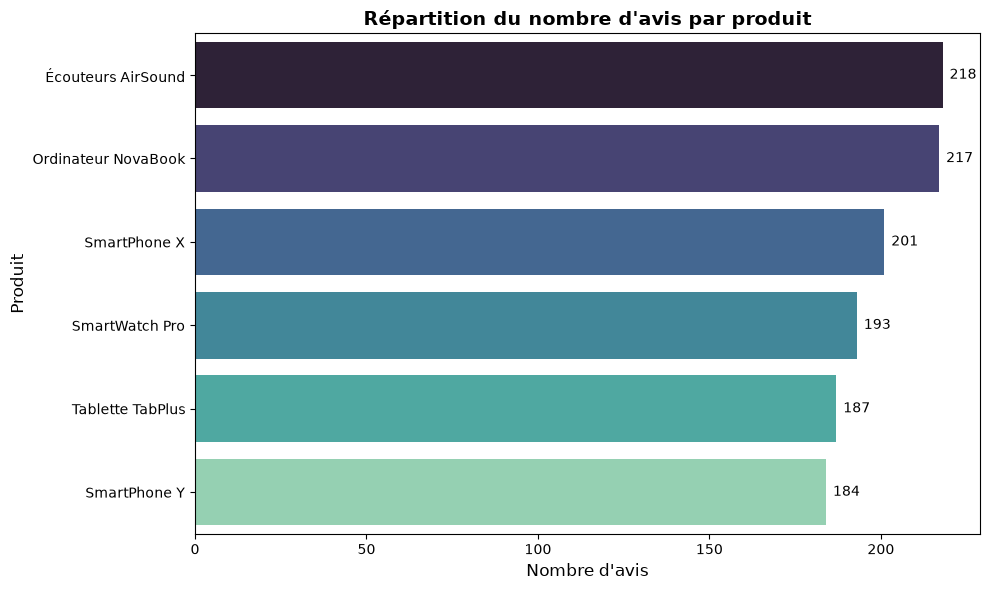

In [211]:
# Configuration de la taille du graphique
plt.figure(figsize=(10, 6))

# Calcul de l'ordre décroissant des produits pour un rendu propre
ordre_produits = df['produit'].value_counts().index

# Création du graphique en barres horizontales (y='produit')
sns.countplot(data=df, y='produit', order=ordre_produits, palette='mako')

# Ajout des titres et labels
plt.title("Répartition du nombre d'avis par produit", fontsize=14, fontweight='bold')
plt.xlabel("Nombre d'avis", fontsize=12)
plt.ylabel("Produit", fontsize=12)

# Ajout des valeurs exactes au bout de chaque barre
ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', 
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()


***Commentaire*** :

Contrairement à la distribution des sources qui présentait une anomalie textuelle, la variable produit ne montre aucun doublon ni problème de casse ('SmartPhone X' et 'SmartPhone Y' sont bien distincts). Le jeu de données dispose d'un volume de retours équitablement distribué pour chaque article (environ 15% à 18% du total des avis par produit). Cette distribution équilibrée est une excellente base pour entraîner un modèle de classification de sentiments, car le modèle disposera de suffisamment d'exemples textuels pour chaque contexte produit.



### Partie 2 – Nettoyage 

##### 1) Supprimer les lignes contenant des valeurs manquantes de texte 

In [212]:
# Étape 1 : On Remplace d'abbord les chaînes vides (ou espaces) par NaN pour les détecter
df['texte'] = df['texte'].replace(r'^\s*$', None, regex=True)

# Étape 2 : On Supprime ensuite toutes les lignes contenant des valeurs manquantes (NaN) dans cette colonne
df = df.dropna(subset=['texte'])
df

,id_avis,date,source,produit,texte,sentiment,note,langue,type_de_texte,longueur,a_emojis,a_urls,a_hashtags,a_mentions,a_chiffres,a_ponctuation_repetee,a_caracteres_speciaux
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr,texte normal,47.0,False,False,False,False,False,False,True
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr,texte contenant un hashtag,35.0,True,False,True,False,False,False,True
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr,texte normal,37.0,False,False,False,False,False,False,True
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr,texte avec beaucoup de ponctuation,46.0,False,False,False,False,False,True,True
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr,texte en majuscules,55.0,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,AV1196,2026-08-07,mobile,SmartPhone Y,La batterie se décharge beaucoup trop vite.,negatif,2,fr,texte normal,43.0,False,False,False,False,False,False,True
1196,AV1197,2026-01-31,email,Écouteurs AirSound,"Très bonne expérience, simple et efficace. !!!",positif,5,fr,texte avec beaucoup de ponctuation,46.0,False,False,False,False,False,True,True
1197,AV1198,2026-04-02,web,SmartWatch Pro,Produit correct pour son prix. !!!,neutre,4,fr,texte avec beaucoup de ponctuation,34.0,False,False,False,False,False,True,True
1198,AV1199,2026-05-02,email,Tablette TabPlus,Excellent rapport qualité-prix. #avis,positif,5,fr,texte contenant un hashtag,37.0,False,False,True,False,False,False,True


##### 2) Supprimer les doublons 

In [213]:
# On Supprime les lignes dupliquées en se basant uniquement sur la colonne 'texte'
df = df.drop_duplicates(subset=['texte'], keep='first')
df

,id_avis,date,source,produit,texte,sentiment,note,langue,type_de_texte,longueur,a_emojis,a_urls,a_hashtags,a_mentions,a_chiffres,a_ponctuation_repetee,a_caracteres_speciaux
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr,texte normal,47.0,False,False,False,False,False,False,True
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr,texte contenant un hashtag,35.0,True,False,True,False,False,False,True
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr,texte normal,37.0,False,False,False,False,False,False,True
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr,texte avec beaucoup de ponctuation,46.0,False,False,False,False,False,True,True
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr,texte en majuscules,55.0,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169,AV1170,2026-04-08,mobile,Écouteurs AirSound,"Très bonne expérience, simple et efficace. htt...",positif,5,fr,texte contenant une URL,76.0,False,True,False,False,True,False,True
1172,AV1173,2026-01-22,web,Écouteurs AirSound,La batterie tient vraiment bien et l'écran est...,positif,5,fr,texte contenant une URL,89.0,False,True,False,False,True,False,True
1185,AV1186,2026-01-29,mobile,SmartPhone X,Excellent rapport qualité-prix. https://exampl...,positif,5,fr,texte contenant une URL,65.0,False,True,False,False,True,False,True
1191,AV1192,2026-06-10,email,Tablette TabPlus,L'utilisation est assez simple. https://exampl...,neutre,4,fr,texte contenant une URL,65.0,False,True,False,False,True,False,True


##### 3) Supprimer les URLs

In [214]:
# On remplace les URLs commençant par http, https ou www par une chaîne vide
df['texte'] = df['texte'].str.replace(r'https?://\S+|www\.\S+', '', regex=True)

# on Nettoies ensuite les espaces doubles créés par la suppression du lien
df['texte'] = df['texte'].str.replace(r'\s+', ' ', regex=True).str.strip()


##### 4) Traiter les mentions et hashtags avec la stratégie la plus pertinente pour une classification de sentiment 

In [215]:
# En premier lieu on supprime complètement les mentions (@quelquun)
df['texte'] = df['texte'].str.replace(r'@\w+', '', regex=True)

# Puis on supprime uniquement le symbole '#' mais conserver le mot qui suit
df['texte'] = df['texte'].str.replace(r'#(\w+)', r'\1', regex=True)

##### 5) Nettoyer les espaces 

In [216]:
# On remplace les espaces multiples, tabulations et retours à la ligne par un seul espace
df['texte'] = df['texte'].str.replace(r'\s+', ' ', regex=True)

# puis on supprime les espaces invisibles au tout début et à la toute fin du texte
df['texte'] = df['texte'].str.strip()

##### 6) Traiter la ponctuation avec la stratégie la plus pertinente pour une classification de sentiment 

En classification de sentiment, supprimer toute la ponctuation aveuglément est une erreur, car certains signes contiennent une forte charge émotionnelle. La stratégie la plus pertinente consiste à effectuer un traitement différencié :

1. Conserver la ponctuation expressive (! et ?) : Les points d'exclamation et d'interrogation traduisent l'intensité (la colère, la surprise, la joie ou l'exaspération). On les isole en ajoutant un espace avant et après pour qu'ils soient traités comme des mots à part entière par le modèle.

2. Supprimer la ponctuation neutre (points, virgules, points-virgules, guillemets) : Ces signes n'apportent aucune valeur sémantique pour comprendre le sentiment et surchargent inutilement le texte. On les remplace par un espace vide.

In [217]:
import string

# 1. Isolons et normalisons la ponctuation expressive (! et ?)
df['texte'] = df['texte'].str.replace(r'!+', ' ! ', regex=True)
df['texte'] = df['texte'].str.replace(r'\?+', ' ? ', regex=True)

# 2. Créons la liste des ponctuations neutres à supprimer (tout sauf ! et ?)
ponctuation_neutre = string.punctuation.replace('!', '').replace('?', '')

# 3. Supprimer la ponctuation neutre du texte
table_nettoyage = str.maketrans(ponctuation_neutre, ' ' * len(ponctuation_neutre))
df['texte'] = df['texte'].str.translate(table_nettoyage)


##### 7) Créer une fonction de nettoyage pour automatiser les actions ci-dessus 

In [218]:
def nettoyer_texte_sentiment(texte):
    if pd.isna(texte):
        return ""
    
    texte_clean = str(texte)
    
    texte_clean = re.sub(r'https?://\S+|www\.\S+', '', texte_clean)
    
    texte_clean = re.sub(r'@\w+', '', texte_clean)      # On supprime les @mentions
    texte_clean = re.sub(r'#(\w+)', r'\1', texte_clean) # On garde le mot mais on vire le '#'
    
    texte_clean = re.sub(r'!+', ' ! ', texte_clean)
    texte_clean = re.sub(r'\?+', ' ? ', texte_clean)
    
    ponctuation_neutre = string.punctuation.replace('!', '').replace('?', '')
    table_traduction = str.maketrans(ponctuation_neutre, ' ' * len(ponctuation_neutre))
    texte_clean = texte_clean.translate(table_traduction)
    
    texte_clean = re.sub(r'\s+', ' ', texte_clean) 
    texte_clean = texte_clean.strip().lower()    
    
    return texte_clean

##### 8) Stocker sur une colonne texte_clean, les textes ayant subi les traitements ci-dessus 

In [219]:
df['texte'] = df['texte'].replace(r'^\s*$', None, regex=True)
df = df.dropna(subset=['texte'])

# Application de la fonction pour créer la nouvelle colonne 'texte_clean'
df['texte_clean'] = df['texte'].apply(nettoyer_texte_sentiment)

df = df.drop_duplicates(subset=['texte_clean'], keep='first')

##### 9) Vérifier le contenu des colonnes texte et texte_clean sur les 10 premières observations 

In [220]:
df[['texte', 'texte_clean']].head(10)

,texte,texte_clean
0,Très bonne expérience simple et efficace,très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 avis,très satisfait de mon achat 👍 avis
2,Produit parfait rien à signaler,produit parfait rien à signaler
3,Produit excellent je suis très satisfait !,produit excellent je suis très satisfait !
4,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...,la batterie tient vraiment bien et l écran est...
5,Très satisfait de mon achat 👍 😊,très satisfait de mon achat 👍 😊
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,service client réactif et commande reçue rapid...
7,Très satisfait de mon achat 👍,très satisfait de mon achat 👍
8,Le produit correspond globalement à la descrip...,le produit correspond globalement à la descrip...
9,Livraison rapide et produit conforme à mes att...,livraison rapide et produit conforme à mes att...


### Partie 3 – Tokenisation

##### 1) Pourquoi split() n'est-il pas suffisant pour une vraie application NLP ? 

La méthode native split() de Python se contente de couper une chaîne de caractères à chaque espace. Elle n'est pas suffisante pour du NLP professionnel pour plusieurs raisons clés :

--La ponctuation reste collée aux mots : Si un texte contient "Génial !", split() va créer le token "Génial !". Le modèle pensera que "Génial" et "Génial !" sont deux mots totalement différents.

--La mauvaise gestion des apostrophes (en français) : Sur le texte "l'ordinateur", split() va générer un seul token "l'ordinateur". Un vrai tokeniseur NLP (comme ceux de NLTK ou SpaCy) séparera correctement l'article du nom : ["l'", "ordinateur"].

--Les mots composés et les caractères spéciaux : split() ne sait pas gérer intelligemment les structures complexes (dates, traits d'union, emojis collés au texte).

##### 2) Utiliser la bibliothèque NLTK pour déterminer : 
##### a) le nombre de tokens de chaque texte

In [221]:
import nltk

df['tokens'] = df['texte_clean'].apply(lambda x: nltk.word_tokenize(str(x)))

# On déterminer le nombre de tokens de chaque texte
df['nb_tokens'] = df['tokens'].apply(len)

print("--- Vérification des 10 premières lignes ---")
df[['texte_clean', 'nb_tokens']].head(10)

--- Vérification des 10 premières lignes ---


,texte_clean,nb_tokens
0,très bonne expérience simple et efficace,6
1,très satisfait de mon achat 👍 avis,7
2,produit parfait rien à signaler,5
3,produit excellent je suis très satisfait !,7
4,la batterie tient vraiment bien et l écran est...,10
5,très satisfait de mon achat 👍 😊,7
6,service client réactif et commande reçue rapid...,7
7,très satisfait de mon achat 👍,6
8,le produit correspond globalement à la descrip...,7
9,livraison rapide et produit conforme à mes att...,8


##### b) nombre moyen de tokens 

In [222]:
# 0n calcule le nombre moyen de tokens sur l'ensemble de notre jeu de données
nombre_moyen_tokens = df['nb_tokens'].mean()
print("\n--- Analyse Statistique ---")
print(f"Le nombre moyen de tokens par texte est de : {nombre_moyen_tokens:.2f}")


--- Analyse Statistique ---
Le nombre moyen de tokens par texte est de : 8.15


#### c) texte avec le plus grand nombre de tokens

In [223]:
index_max = df['nb_tokens'].idxmax()

texte_plus_long = df.loc[index_max, 'texte_clean']
nb_tokens_max = df.loc[index_max, 'nb_tokens']

print("---Texte avec le plus grand nombre de tokens---")
print(f"Nombre de tokens max : {nb_tokens_max}")
print(f"Texte nettoyé    : {texte_plus_long}")

---Texte avec le plus grand nombre de tokens---
Nombre de tokens max : 120
Texte nettoyé    : le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue le produit est bien mais la livraison a été longue


##### d) texte avec le plus petit nombre de tokens. 

In [224]:
index_min = df['nb_tokens'].idxmin()

texte_plus_court = df.loc[index_min, 'texte_clean']
nb_tokens_min = df.loc[index_min, 'nb_tokens']

print("--- Texte avec le plus petit nombre de tokens ---")
print(f"Nombre de tokens : {nb_tokens_min}")
print(f"Texte nettoyé    : {texte_plus_court}")

--- Texte avec le plus petit nombre de tokens ---
Nombre de tokens : 1
Texte nettoyé    : ok


### Partie 4 – Normalisation 

##### 1) Uniformiser la casse en minuscules. Pourquoi ce traitement ? 

Passer tout le texte en minuscules (ex: avec .str.lower()) permet d'harmoniser le vocabulaire et de réduire la dimensionnalité du problème.

Pour une machine, les chaînes "Génial", "génial" et "GÉNIAL" sont trois entités mathématiques totalement différentes. En convertissant tout en minuscules, on fusionne ces variantes en un seul mot-clé unique ("génial"). Cela évite au modèle de devoir apprendre séparément le sens d'un mot selon qu'il soit placé en début ou au milieu d'une phrase.

##### 2) Faut-il systématiquement supprimer les accents dans un corpus français ? 

***Non, il ne faut pas supprimer systématiquement les accents en français.***

Si la suppression des accents simplifiait autrefois les calculs (époque du codage ASCII), elle crée aujourd'hui de graves ambiguïtés sémantiques qui dégradent les performances des modèles modernes.

Exemple : Sans accents, les mots "côte" (littoral), "cote" (évaluation/popularité) et "coté" (valorisé) deviennent tous identiques ("cote"). Le modèle perd alors le contexte et le sens réel du message.Dans votre cas (analyse de sentiment), conserver les accents permet de garder toute la richesse de la langue française.

##### 3) Quels stop words supprimer ? 

Il faut supprimer les mots outils grammaticaux totalement neutres, c'est-à-dire ceux qui n'apportent aucun indice sur l'émotion ou l'opinion de l'utilisateur. Ce sont généralement :

--Les articles définis et indéfinis : le, la, les, un, une, des

--Les prépositions : de, du, à, dans, par, pour, en, vers

--Les pronoms personnels sujets ou objets sans valeur affective : je, tu, il, nous, vous, ils, le, la, leur

--Les conjonctions de coordination neutres : et, ou

##### 4) Quels stop words conserver ?

En classification de sentiment, certains mots classés par défaut comme "stop words" dans les dictionnaires (comme NLTK ou SpaCy) sont en réalité cruciaux et doivent absolument être conservés :

  ***Les négations:***  Des mots comme ne, pas, plus, jamais, rien changent radicalement le sens d'une phrase. Si on supprime "pas", la phrase "Ce produit n'est pas bon" devient "Ce produit est bon", ce qui fausse totalement la prédiction du modèle.

  ***Les conjonctions d'opposition :*** Le mot mais (ex: "Le design est beau mais l'écran est cassé") indique un basculement de sentiment crucial pour l'analyse.

  ***Les adverbes d'intensité :*** Des mots comme très, trop, intensément qualifient la force d'un sentiment et restent utiles si l'on cherche à nuancer la polarité (ex: très positif vs modérément positif).

##### 5) Appliquer la technique (stemming ou lemmatisation) la plus adaptée ? 

La technique la plus adaptée pour un corpus en français orienté analyse de sentiments est la ***lemmatisation.***

***Pourquoi ?*** Le stemming (racinisation) coupe brutalement la fin des mots pour ne garder qu'une racine (ex: "aimable" et "aimer" deviendraient "aim"). Cela détruit parfois la nuance du mot. La lemmatisation ramène le mot à sa forme du dictionnaire (les verbes à l'infinitif, les noms au singulier : ex: "meilleures" devient "bon" ou "meilleur"). Cela préserve le sens exact et la grammaire, ce qui est crucial pour comprendre la subtilité d'un avis client.



In [225]:
import spacy
import re
from nltk.corpus import stopwords
import string

# Chargement du modèle français
nlp = spacy.load('fr_core_news_sm')

# Ajout explicite de 'avoir' et 'être' dans les stop words à éliminer 
mots_vides_traditionnels = set(stopwords.words('french'))
mots_vides_traditionnels.update({'avoir', 'être', 'avoirs', 'êtres'}) 

mots_a_garder = {'ne', 'pas', 'plus', 'jamais', 'rien', 'aucun', 'aucune', 'mais', 'trop', 'très'}
stop_words_final = mots_vides_traditionnels - mots_a_garder

# 3. Fonction de lemmatisation
def lemmatiser_texte_corrige(texte_clean):
    if pd.isna(texte_clean):
        return ""
        
    texte_clean = re.sub(r'(.)\1{2,}', r'\1', str(texte_clean))
    
    doc = nlp(texte_clean)
    tokens_lemmatises = []
    
    for token in doc:
        lemme = token.lemma_.lower().strip()
        
        if lemme in ['avi', 'avir']:
            lemme = 'avis'
        if lemme == 'parfaire' and token.text.lower() == 'parfait':
            lemme = 'parfait'
            
        # Filtrage final
        if lemme not in stop_words_final and lemme not in string.punctuation and len(lemme) > 1:
            tokens_lemmatises.append(lemme)
            
    return " ".join(tokens_lemmatises)


##### 6) Stocker sur une colonne « texte_final », les textes ayant subi le nettoyage et les traitements ci-dessus 

In [226]:
df['texte_final'] = df['texte_clean'].apply(lemmatiser_texte_corrige)

##### 7) Vérifier le contenu des colonnes texte, texte_clean et texte_final sur les 10 premières observations 

In [227]:
print("--- COMPARATIF AVEC LEMMATISATION (10 premières lignes) ---")
df[['texte', 'texte_clean', 'texte_final']].head(10)

--- COMPARATIF AVEC LEMMATISATION (10 premières lignes) ---


,texte,texte_clean,texte_final
0,Très bonne expérience simple et efficace,très bonne expérience simple et efficace,très bon expérience simple efficace
1,Très satisfait de mon achat 👍 avis,très satisfait de mon achat 👍 avis,très satisfait achat avis
2,Produit parfait rien à signaler,produit parfait rien à signaler,produit parfait rien signaler
3,Produit excellent je suis très satisfait !,produit excellent je suis très satisfait !,produit excellent très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...,la batterie tient vraiment bien et l écran est...,batterie tenir vraiment bien écran superbe
5,Très satisfait de mon achat 👍 😊,très satisfait de mon achat 👍 😊,très satisfait achat
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,service client réactif et commande reçue rapid...,service client réactif commande recevoir rapid...
7,Très satisfait de mon achat 👍,très satisfait de mon achat 👍,très satisfait achat
8,Le produit correspond globalement à la descrip...,le produit correspond globalement à la descrip...,produit correspondre globalement description
9,Livraison rapide et produit conforme à mes att...,livraison rapide et produit conforme à mes att...,livraison rapide produire conforme attente


##### 8) Sauvegarder le dataset nettoyé dans le fichier smart_reviews_cleaned.csv

In [228]:
df.to_csv('smart_reviews_cleaned.csv', index=False, encoding='utf-8')
print("Fichier 'smart_reviews_cleaned.csv' sauvegardé avec succès avec lemmatisation !")

Fichier 'smart_reviews_cleaned.csv' sauvegardé avec succès avec lemmatisation !


### Partie 5 – Découpage Train/Test 

In [229]:
from sklearn.model_selection import train_test_split

X = df['texte_final']

y = df['sentiment']

# Découpage en ensembles de Train et de Test avec les conditions requises
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,          # cette ligne represente 20% des données pour le test
    random_state=42,         # cette ligne garantit la reproductibilité du découpage
    stratify=y               # cette ligne conserve les proportions de classes (Stratification)
)

### Partie 6 – Vectorisation 
##### 1) Utiliser la technique « Bag of Words » pour générer et afficher la taille et un extrait du vocabulaire ainsi qu’un morceau de la matrice 

In [230]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialisation et application du Bag of Words
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)

# Récupération du vocabulaire COMPLET (liste de tous les mots uniques retenus)
vocab_bow = bow_vectorizer.get_feature_names_out()

print("=== 1) RÉSULTATS BAG OF WORDS ===")
print(f"Taille du vocabulaire BoW : {len(vocab_bow)} mots uniques.")

print("\nVocabulaire complet (tous les mots) :")
print(list(vocab_bow))

# On affiche un morceau de la matrice 
df_extrait_bow = pd.DataFrame(
    X_train_bow[:10, :10].toarray(), 
    columns=vocab_bow[:10]
)
print("\nMorceau de la matrice BoW :")
df_extrait_bow


=== 1) RÉSULTATS BAG OF WORDS ===
Taille du vocabulaire BoW : 71 mots uniques.

Vocabulaire complet (tous les mots) :
['achat', 'assez', 'attente', 'avis', 'batterie', 'beaucoup', 'bien', 'bon', 'client', 'commande', 'conforme', 'correct', 'correspondre', 'demande', 'description', 'déception', 'décevant', 'décharge', 'déjà', 'dérouler', 'déçu', 'efficace', 'endommager', 'excellent', 'exceptionnelle', 'expérience', 'fonctionner', 'globalement', 'livraison', 'long', 'mauvais', 'mécontent', 'ne', 'normalement', 'ok', 'parfait', 'parfaitement', 'pas', 'plus', 'prix', 'produire', 'produit', 'qualité', 'rapide', 'rapidement', 'rapport', 'recevoir', 'recommander', 'rendez', 'rien', 'réactif', 'répondre', 'sans', 'satisfait', 'service', 'signaler', 'simple', 'super', 'superbe', 'temps', 'tenir', 'tout', 'trop', 'très', 'utilisation', 'venir', 'vite', 'vivement', 'voir', 'vraiment', 'écran']

Morceau de la matrice BoW :


,achat,assez,attente,avis,batterie,beaucoup,bien,bon,client,commande
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,1,0
7,0,0,0,1,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0


##### 2) Utiliser la technique « TF-IDF » pour générer et afficher la taille et un extrait du vocabulaire ainsi qu’un morceau de la matrice 

In [231]:
from sklearn.feature_extraction.text import TfidfVectorizer

# On initialise le vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer()

# On entraîne et transforme sur notre ensemble d'entraînement (X_train)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# On recupere notre vocabulaire final
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print("=== 2) RÉSULTATS TECHNIQUE TF-IDF ===")

# On affiche de la TAILLE du vocabulaire
print(f"Taille du vocabulaire TF-IDF : {len(vocab_tfidf)} mots uniques.\n")

print("Vocabulaire complet nettoyé :")
print(list(vocab_tfidf))

df_extrait_tfidf = pd.DataFrame(
    X_train_tfidf[:5, :10].toarray(), 
    columns=vocab_tfidf[:10]
)

print("\nMorceau de la matrice TF-IDF :")
df_extrait_tfidf.round(4) 

=== 2) RÉSULTATS TECHNIQUE TF-IDF ===
Taille du vocabulaire TF-IDF : 71 mots uniques.

Vocabulaire complet nettoyé :
['achat', 'assez', 'attente', 'avis', 'batterie', 'beaucoup', 'bien', 'bon', 'client', 'commande', 'conforme', 'correct', 'correspondre', 'demande', 'description', 'déception', 'décevant', 'décharge', 'déjà', 'dérouler', 'déçu', 'efficace', 'endommager', 'excellent', 'exceptionnelle', 'expérience', 'fonctionner', 'globalement', 'livraison', 'long', 'mauvais', 'mécontent', 'ne', 'normalement', 'ok', 'parfait', 'parfaitement', 'pas', 'plus', 'prix', 'produire', 'produit', 'qualité', 'rapide', 'rapidement', 'rapport', 'recevoir', 'recommander', 'rendez', 'rien', 'réactif', 'répondre', 'sans', 'satisfait', 'service', 'signaler', 'simple', 'super', 'superbe', 'temps', 'tenir', 'tout', 'trop', 'très', 'utilisation', 'venir', 'vite', 'vivement', 'voir', 'vraiment', 'écran']

Morceau de la matrice TF-IDF :


,achat,assez,attente,avis,batterie,beaucoup,bien,bon,client,commande
0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0
1,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0
2,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.493,0.0,0.0
3,0.7206,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0
4,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0


##### 3) Utiliser la technique « TF-IDF avec des unigrams et bigrams » pour générer et afficher la taille et un extrait du vocabulaire ainsi qu’un morceau de la matrice 

In [232]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialisation avec le paramètre ngram_range=(1, 2)
# (1, 2) signifie : extraire les n-grams allant de la taille 1 jusqu'à la taille 2
tfidf_ngram_vectorizer = TfidfVectorizer(ngram_range=(1, 2))

# on entraîne et transforme sur votre ensemble d'entraînement (X_train)
X_train_ngram = tfidf_ngram_vectorizer.fit_transform(X_train)

# Récupération du nouveau vocabulaire augmenté
vocab_ngram = tfidf_ngram_vectorizer.get_feature_names_out()

print("=== 3) RÉSULTATS TF-IDF (UNIGRAMS + BIGRAMS) ===")

# Affichage de la TAILLE du vocabulaire (elle va être beaucoup plus grande !)
print(f"Taille du vocabulaire augmenté : {len(vocab_ngram)} éléments (mots + couples de mots).\n")

print("Extrait du vocabulaire augmenté (30 premiers éléments) :")
print(list(vocab_ngram[:30]))

df_extrait_ngram = pd.DataFrame(
    X_train_ngram[:5, :10].toarray(), 
    columns=vocab_ngram[:10]
)

print("\nMorceau de la matrice:")
df_extrait_ngram.round(4)

=== 3) RÉSULTATS TF-IDF (UNIGRAMS + BIGRAMS) ===
Taille du vocabulaire augmenté : 170 éléments (mots + couples de mots).

Extrait du vocabulaire augmenté (30 premiers éléments) :
['achat', 'assez', 'assez simple', 'attente', 'avis', 'batterie', 'batterie décharge', 'batterie tenir', 'beaucoup', 'beaucoup trop', 'bien', 'bien écran', 'bon', 'bon expérience', 'bon produit', 'client', 'client pas', 'client réactif', 'commande', 'commande recevoir', 'conforme', 'conforme attente', 'correct', 'correct prix', 'correct sans', 'correspondre', 'correspondre globalement', 'demande', 'demande avis', 'description']

Morceau de la matrice:


,achat,assez,assez simple,attente,avis,batterie,batterie décharge,batterie tenir,beaucoup,beaucoup trop
0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.5291,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
